# 2D Profile Scan with Nuisance Parameters

`Optimizer.profile` allows for profiling over 1D and 2D likelihoods while
fitting over nuisance parameters.

In [1]:
import astropy.units as u
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

import nyx
from nyx import (
    Airglow,
    EffectiveApertureInstrument,
    Geometry,
    Moon,
    Observation,
    Optimizer,
    Scene,
    SingleScattering,
    Stars,
    ZodiacalLight,
    dump_params,
    freeze_all,
    unfreeze,
)

nyx.configure()

EFFICIENCY = "instruments.instrument.efficiency"
AOD = "atmosphere.components.Mie.aod_500"

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 30) * u.nm,  # wavelength grid
    nside=16,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

instrument = EffectiveApertureInstrument.from_iactrace_table(geo, "CT1_aperture.npz")
atmosphere = SingleScattering.from_hg_ozone(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

In [11]:
location = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
times = Time("2021-06-11T19:00:00", scale="utc") + jnp.linspace(0, 60, 12) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs = Observation(location, times, target, geo)
scene = Scene.build(instrument, atmosphere, sources, obs)

In [25]:
TRUE_EFFICIENCY, TRUE_AOD = 0.63, 0.22

truth = scene.set_params({EFFICIENCY: TRUE_EFFICIENCY, AOD: TRUE_AOD})
truth = truth.set(
    "instruments.instrument.shift",
    jnp.asarray(np.deg2rad(np.random.default_rng(41).uniform(-0.03, 0.03, size=(obs.nobs, 2)))),
)

rng = np.random.default_rng(42)
rel_error = 0.05
rates = truth.render()["instrument"]
data = jnp.asarray(np.asarray(rates) * rng.lognormal(0.0, rel_error, size=rates.shape))

The two scanned parameters plus the pointing, which is the nuisance the scan
refits at every node.

In [37]:
%%time
start = unfreeze(freeze_all(scene), EFFICIENCY, AOD, "instruments.instrument.shift")


def residuals(scene):
    return (jnp.log(scene.render()["instrument"]) - jnp.log(data)) / rel_error


opt = Optimizer(residuals, optx.LBFGS(rtol=1e-7, atol=1e-7))
fitted, sol = opt.run(start, max_steps=512, throw=False)
errors = opt.errors(fitted)

best = dump_params(fitted)
sigma = dump_params(errors)
print(opt.summary(fitted, sol))
for name in (EFFICIENCY, AOD):
    print(f"{name:40s} {float(best[name]):.4f} +- {float(sigma[name]):.4f}")

FitSummary(
  chi2         11640.4
  d.o.f.       11494 = 11520 data - 26 free
  chi2/d.o.f.  1.01274
  solver       converged, 197 steps
)
instruments.instrument.efficiency        0.6325 +- 0.0015
atmosphere.components.Mie.aod_500        0.2352 +- 0.0077
CPU times: user 17.4 s, sys: 1.15 s, total: 18.5 s
Wall time: 10.7 s


In [42]:
%%time


def axis(name, n, k=3.0, floor=0.0):
    lo = max(float(best[name]) - k * float(sigma[name]), floor)
    hi = float(best[name]) + k * float(sigma[name])
    return np.linspace(lo, hi, n)


grid = opt.profile(
    fitted,
    {EFFICIENCY: axis(EFFICIENCY, 25), AOD: axis(AOD, 24, floor=1e-3)},
    max_steps=512,
    callback=lambda *_: print(".", end="", flush=True),
)
print()
print(grid)

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................
ProfileGrid(instruments.instrument.efficiency in [0.628, 0.637] (25), atmosphere.components.Mie.aod_500 in [0.212, 0.2583] (24))
  best chi2 11640.8 at instruments.instrument.efficiency=0.63212, atmosphere.components.Mie.aod_500=0.234157
  1/2/3 sigma at delta chi2 (2.3, 6.18, 11.83)
CPU times: user 12min 7s, sys: 1min 4s, total: 13min 11s
Wall time: 12min 6s


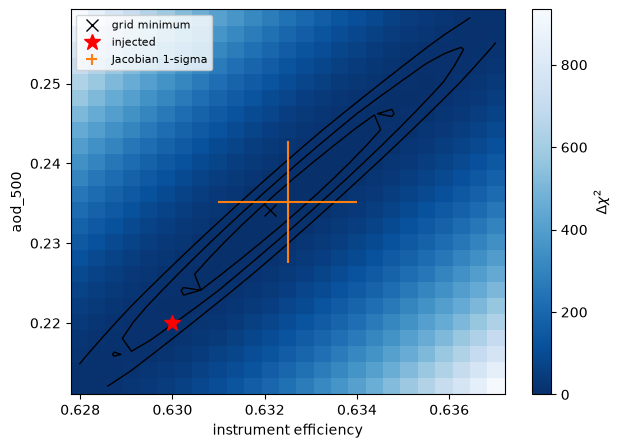

In [43]:
x, y = grid.axes
z = grid.delta_chi2.T

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(x, y, z, shading="nearest", cmap="Blues_r")
ax.contour(x, y, z, levels=grid.levels, colors="k", linewidths=1)
ax.plot(*grid.best.values(), "kx", ms=9, label="grid minimum")
ax.plot(TRUE_EFFICIENCY, TRUE_AOD, "r*", ms=12, label="injected")
ax.errorbar(
    float(best[EFFICIENCY]),
    float(best[AOD]),
    xerr=float(sigma[EFFICIENCY]),
    yerr=float(sigma[AOD]),
    fmt="none",
    ecolor="C1",
    label="Jacobian 1-sigma",
)
ax.set_xlabel("instrument efficiency")
ax.set_ylabel("aod_500")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(mesh, label=r"$\Delta \chi^2$")